# Preprocessing & Region Split — 2026-03-05

**Single notebook that goes from raw GeoPackage → ready-to-model parquet files.**

| Step | What happens |
|------|--------------|
| 1 | Load raw bank-point data and scope regions from GeoPackage |
| 2 | Run `DataHandler` to compute `distance_to_erosion_border` per region × year |
| 3 | Save `processed_erosion_data.parquet` (intermediate, also used by `model_evaluation`) |
| 4 | Build feature table (`v_train`, `v_test`, distances, timestamps) |
| 5 | Stratified 80/20 train/test split per cluster |
| 6 | Sanity checks (distribution, NVO balance) |
| 7 | Save `region_split.parquet` + `region_inference_only.parquet` |

**Input data:**  `wocu_output_fase2_20260210.gpkg`  
**Output files:** see Section 7 for exact paths with timestamps.

> ⚠️ Re-running this notebook regenerates the split. All model notebooks that load
> `region_split.parquet` will be affected. Only re-run when you intend to change
> the preprocessing or the input data.

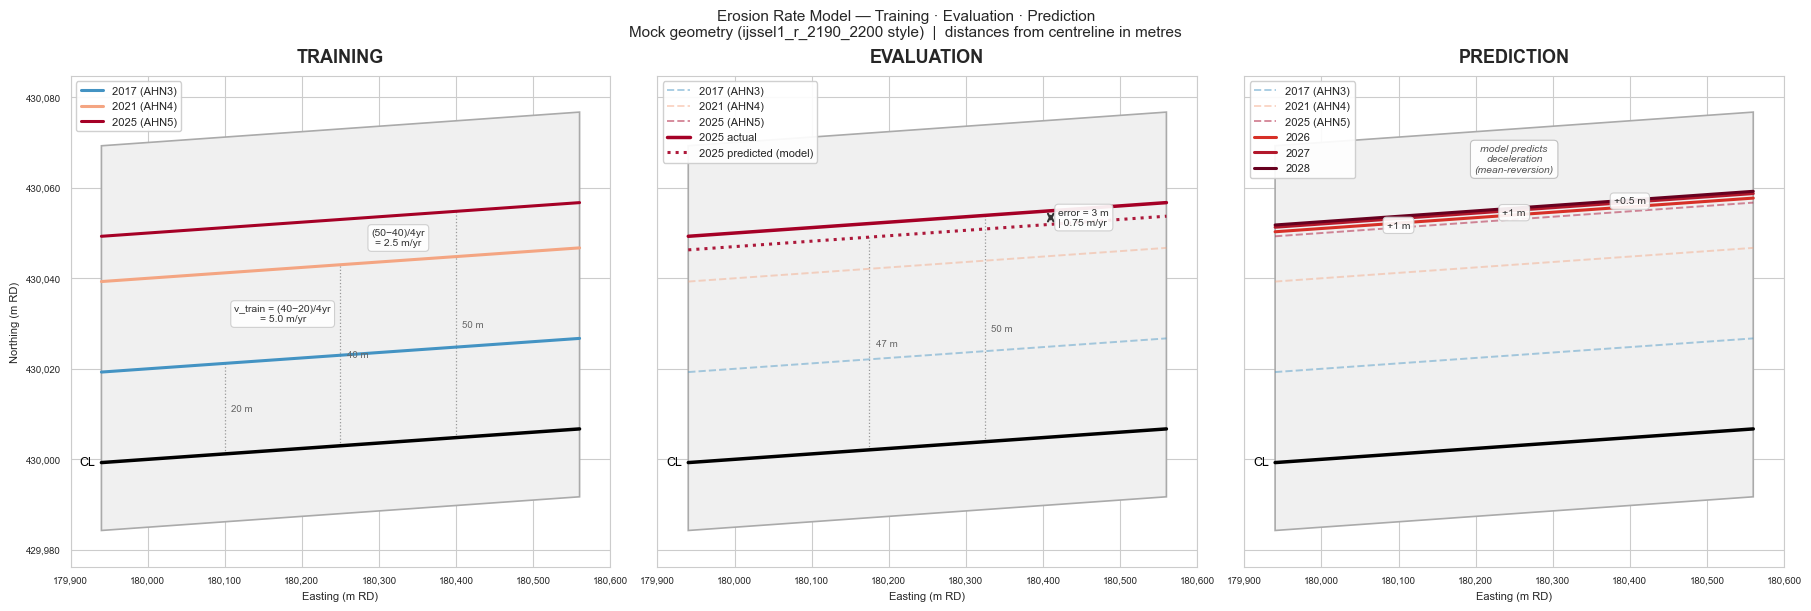

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Mock geometry — CL at bottom, bank lines extend upward ────────────────────
# x = along-CL distance (m),  y = perpendicular distance from CL (m)
# A slight cosmetic tilt is added so the scope looks like a real region.
CL_LEN = 500.         # scope length along CL (m)
TILT   = 6.           # y-rise across full scope width (cosmetic tilt, m)
RD     = np.array([180_000., 430_000.])  # RD display offset

def cl_y(x):
    return TILT * np.asarray(x, float) / CL_LEN

# Scope polygon
sx = np.array([-60., CL_LEN + 60, CL_LEN + 60, -60.])
scope = np.column_stack([sx, np.array([cl_y(sx[0]) - 15, cl_y(sx[1]) - 15,
                                        cl_y(sx[2]) + 70, cl_y(sx[3]) + 70])])

# Bank-line helpers
_BX = np.array([-60., CL_LEN + 60])

def bank_ys(dist):
    return cl_y(_BX) + dist

def pt(dist, xfrac=0.5):
    x = xfrac * CL_LEN
    return np.array([x + RD[0], cl_y(x) + dist + RD[1]])

# ── Colours & style ──────────────────────────────────────────────────────────
C = {'t1':'#4393c3', 't2':'#f4a582', 't3':'#a50026',
     'f1':'#d73027', 'f2':'#b2182b', 'f3':'#67001f'}
DOTTED = dict(color='#999999', lw=0.9, ls=':', zorder=4)
HIST   = [(20, C['t1'], '2017 (AHN3)'),
           (40, C['t2'], '2021 (AHN4)'),
           (50, C['t3'], '2025 (AHN5)')]

# ── Plot helpers ─────────────────────────────────────────────────────────────
def draw_base(ax):
    ax.fill(scope[:,0]+RD[0], scope[:,1]+RD[1],
            fc='#f0f0f0', ec='#aaaaaa', lw=1.2, zorder=1)
    ax.plot(_BX+RD[0], cl_y(_BX)+RD[1],
            color='black', lw=2.5, solid_capstyle='round', zorder=5)
    ax.text(_BX[0]+RD[0]-8, cl_y(_BX[0])+RD[1],
            'CL', fontsize=9, color='black', va='center', ha='right')

def draw_line(ax, dist, color, ls='-', alpha=1., lw=2.2, label=None):
    ax.plot(_BX+RD[0], bank_ys(dist)+RD[1],
            color=color, lw=lw, ls=ls, alpha=alpha, zorder=6, label=label)

def draw_perp(ax, dist, label=None, xfrac=0.5):
    x = xfrac * CL_LEN
    p0 = np.array([x+RD[0], cl_y(x)+RD[1]])
    p1 = np.array([x+RD[0], cl_y(x)+dist+RD[1]])
    ax.plot([p0[0],p1[0]], [p0[1],p1[1]], **DOTTED)
    if label:
        ax.text(p1[0]+8, (p0[1]+p1[1])/2, label,
                fontsize=7, color='#666666', ha='left', va='center', zorder=7)

def boxlabel(ax, pos, text, **kw):
    ax.text(pos[0], pos[1], text,
            fontsize=7.5, color='#333333', ha='center', va='center', zorder=9,
            bbox=dict(fc='white', ec='#cccccc', lw=0.8, alpha=0.92,
                      boxstyle='round,pad=0.35'), **kw)

def fmt(ax, title):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Easting (m RD)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
    pad_x, pad_y = 40, 8
    ax.set_xlim(scope[:,0].min()+RD[0]-pad_x, scope[:,0].max()+RD[0]+pad_x)
    ax.set_ylim(scope[:,1].min()+RD[1]-pad_y, scope[:,1].max()+RD[1]+pad_y)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         constrained_layout=True, sharey=True, sharex=True)
axes[0].set_ylabel('Northing (m RD)', fontsize=8)

# ══ Panel 1 — TRAINING ═══════════════════════════════════════════════════════
ax = axes[0]
draw_base(ax)
for dist, color, lbl in HIST:
    draw_line(ax, dist, color, label=lbl)

draw_perp(ax, 20, '20 m', xfrac=0.2)
draw_perp(ax, 40, '40 m', xfrac=0.5)
draw_perp(ax, 50, '50 m', xfrac=0.8)

boxlabel(ax, pt(30, xfrac=0.35), 'v_train = (40−20)/4yr\n= 5.0 m/yr')
boxlabel(ax, pt(45, xfrac=0.65), '(50−40)/4yr\n= 2.5 m/yr')

fmt(ax, 'TRAINING')
ax.legend(loc='upper left', fontsize=8, framealpha=0.92)

# ══ Panel 2 — EVALUATION ═════════════════════════════════════════════════════
ax = axes[1]
draw_base(ax)

# Historical lines — visible but de-emphasised
for dist, color, lbl in HIST:
    draw_line(ax, dist, color, lw=1.4, alpha=0.45, ls='--', label=lbl)

# t3 actual (full emphasis)
draw_line(ax, 50, C['t3'], lw=2.5, label='2025 actual')
# t3 predicted
draw_line(ax, 47, C['t3'], ls=':', lw=2.2, alpha=0.9, label='2025 predicted (model)')

draw_perp(ax, 47, '47 m', xfrac=0.35)
draw_perp(ax, 50, '50 m', xfrac=0.65)

# Double-headed error arrow
arr_xfrac = 0.82
arr_xloc  = arr_xfrac * CL_LEN
p47 = np.array([arr_xloc+RD[0], cl_y(arr_xloc)+47+RD[1]])
p50 = np.array([arr_xloc+RD[0], cl_y(arr_xloc)+50+RD[1]])
ax.annotate('', xy=tuple(p50), xytext=tuple(p47),
            arrowprops=dict(arrowstyle='<->', color='#333333', lw=1.5,
                            mutation_scale=10))
ax.text(p47[0]+10, (p47[1]+p50[1])/2, 'error = 3 m\n| 0.75 m/yr',
        fontsize=7.5, ha='left', va='center', color='#333333',
        bbox=dict(fc='white', ec='#cccccc', lw=0.8, alpha=0.92,
                  boxstyle='round,pad=0.35'), zorder=9)

fmt(ax, 'EVALUATION')
ax.legend(loc='upper left', fontsize=8, framealpha=0.92)

# ══ Panel 3 — PREDICTION ═════════════════════════════════════════════════════
ax = axes[2]
draw_base(ax)

# Historical lines — visible but de-emphasised
for dist, color, lbl in HIST:
    draw_line(ax, dist, color, lw=1.4, alpha=0.45, ls='--', label=lbl)

draw_line(ax, 51,   C['f1'], label='2026')
draw_line(ax, 52,   C['f2'], label='2027')
draw_line(ax, 52.5, C['f3'], label='2028')

for d1, d2, txt, xf in [(50, 51, '+1 m', 0.2),
                         (51, 52, '+1 m', 0.5),
                         (52, 52.5, '+0.5 m', 0.8)]:
    boxlabel(ax, pt((d1+d2)/2, xfrac=xf), txt)

ax.text(*pt(60, xfrac=0.5), 'model predicts\ndeceleration\n(mean-reversion)',
        fontsize=7.5, color='#555555', ha='center', va='bottom', style='italic',
        bbox=dict(fc='white', ec='#bbbbbb', lw=0.8, alpha=0.92,
                  boxstyle='round,pad=0.4'), zorder=9)

fmt(ax, 'PREDICTION')
ax.legend(loc='upper left', fontsize=8, framealpha=0.92)

fig.suptitle(
    'Erosion Rate Model — Training · Evaluation · Prediction\n'
    'Mock geometry (ijssel1_r_2190_2200 style)  |  distances from centreline in metres',
    fontsize=11)
plt.show()

## 1. Setup

In [14]:
import sys
sys.path.insert(0, '../..')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from datetime import datetime

import src.paths as PATHS
import src.constants as CONST
import src.data.config as DATA_CONFIG
import src.data.data_handler as DH

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

# ── Input ─────────────────────────────────────────────────────────────────────
GPKG_PATH = PATHS.DATA_DIR / '01_raw/erosion/wocu_output_fase2_20260210.gpkg'

# ── Output ────────────────────────────────────────────────────────────────────
PROCESSED_OUT  = PATHS.DATA_DIR / '02_processed/erosion/processed_erosion_data.parquet'
SPLIT_OUT      = PATHS.DATA_DIR / '02_processed/erosion/region_split.parquet'
INFERENCE_OUT  = PATHS.DATA_DIR / '02_processed/erosion/region_inference_only.parquet'

# ── Constants ─────────────────────────────────────────────────────────────────
DIST_COL    = CONST.DISTANCE_TO_CENTERLINE
CLUSTERS    = ['ijssel1', 'ijssel2', 'maas1', 'maas2', 'maas3', 'nederrijn', 'rijn']
RANDOM_SEED = 42
TEST_SIZE   = 0.20

def get_cluster(location_id: str) -> str:
    for c in CLUSTERS:
        if location_id.startswith(c):
            return c
    return 'other'

RUN_TIMESTAMP = datetime.now().strftime('%Y-%m-%d %H:%M')
print(f'Run timestamp : {RUN_TIMESTAMP}')
print(f'Input GPKG    : {GPKG_PATH.name}  (exists: {GPKG_PATH.exists()})')
print(f'Output dir    : {PROCESSED_OUT.parent}')
print(f'Random seed   : {RANDOM_SEED}')
print(f'Test fraction : {TEST_SIZE:.0%}')

Run timestamp : 2026-03-04 11:41
Input GPKG    : wocu_output_fase2_20260210.gpkg  (exists: True)
Output dir    : /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/02_processed/erosion
Random seed   : 42
Test fraction : 20%


## 2. Load raw data

In [15]:
print('Loading scope regions...')
scope_regions = gpd.read_file(str(GPKG_PATH), layer='vlakken_scope')
# vlakken_scope uses 'position_id'; DataHandler expects 'location_id'
if 'position_id' in scope_regions.columns:
    scope_regions = scope_regions.rename(columns={'position_id': 'location_id'})
print(f'  {len(scope_regions):,} scope regions')

print('Loading bank points...')
bank_points = gpd.read_file(str(GPKG_PATH), layer='punten_oever')
print(f'  {len(bank_points):,} bank points')

print('Loading centrelines...')
centerlines = gpd.read_file(str(GPKG_PATH), layer='centrelines')
print(f'  {len(centerlines):,} centrelines')

print()
print(f'Bank point columns : {list(bank_points.columns)}')
print(f'Bank point years   : {sorted(bank_points["dtm_date"].unique())}')

Loading scope regions...
  12,130 scope regions
Loading bank points...
  4,844,655 bank points
Loading centrelines...
  12,130 centrelines

Bank point columns : ['z', 'dist', 'type_oever', 'status', 'location_id', 'dtm_version', 'dtm_date', 'geometry']
Bank point years   : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2024), np.int64(2025)]


## 3. Configure and run DataHandler

In [16]:
config = DATA_CONFIG.DataConfiguration(
    prediction_region_id_column_name='location_id',
    timestamp_column_name='dtm_date',
    no_of_points_for_distance_calculation=3,
    use_only_certain_river_bank_points=True,
)

data_handler = DH.DataHandler(
    config=config,
    prediction_regions=scope_regions,
    erosion_data=bank_points,
)

print('Running DataHandler.process_erosion_features()...')
data_handler.process_erosion_features()

processed = data_handler.processed_erosion_data.copy()
processed.index.names = ['location_id', 'year']

print(f'\nDone.')
print(f'  Shape   : {processed.shape}')
print(f'  Columns : {list(processed.columns)}')
print(f'  Regions : {processed.index.get_level_values(0).nunique():,}')
print()
print(processed.head(6))

Setting the number extra features to 0, even though it should be automatically calculated.


Running DataHandler.process_erosion_features()...

Done.
  Shape   : (30228, 2)
  Columns : ['distance_to_centerline', 'timesteps_since_last_measurement']
  Regions : 10,484

                          distance_to_centerline  \
location_id         year                           
ijssel1_l_0000_0010 2017              162.583333   
                    2025              162.083333   
ijssel1_l_0010_0020 2017              155.478645   
                    2022              156.229750   
                    2025              156.730486   
ijssel1_l_0020_0030 2017              168.083333   

                          timesteps_since_last_measurement  
location_id         year                                    
ijssel1_l_0000_0010 2017                               1.0  
                    2025                               8.0  
ijssel1_l_0010_0020 2017                               1.0  
                    2022                               5.0  
                    2025                  

## 4. Save `processed_erosion_data.parquet`

In [17]:
processed.to_parquet(PROCESSED_OUT)
print(f'Saved: {PROCESSED_OUT}')
print(f'  Shape  : {processed.shape}')
print(f'  Written: {RUN_TIMESTAMP}')

Saved: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/02_processed/erosion/processed_erosion_data.parquet
  Shape  : (30228, 2)
  Written: 2026-03-04 11:41


## 5. Timestamp distribution per region

In [18]:
ts_counts = processed.groupby(level=0).size().rename('n_timestamps')

print('Timestamp count distribution across all regions:')
print(f'  {"n_timestamps":<15} {"n_regions":<12} {"% of total"}')
for n, count in ts_counts.value_counts().sort_index().items():
    pct = count / len(ts_counts) * 100
    bar = '█' * int(pct / 2)
    print(f'  {n:<15} {count:<12,} {pct:>5.1f}%  {bar}')

print(f'\nTotal regions : {len(ts_counts):,}')
eligible  = (ts_counts == 3).sum()
infer_only = (ts_counts < 3).sum()
print(f'  Eligible (3 timestamps) : {eligible:,}  ({eligible/len(ts_counts)*100:.1f}%)')
print(f'  Inference only (< 3)    : {infer_only:,}  ({infer_only/len(ts_counts)*100:.1f}%)')

Timestamp count distribution across all regions:
  n_timestamps    n_regions    % of total
  1               142            1.4%  
  2               940            9.0%  ████
  3               9,402         89.7%  ████████████████████████████████████████████

Total regions : 10,484
  Eligible (3 timestamps) : 9,402  (89.7%)
  Inference only (< 3)    : 1,082  (10.3%)


## 6. Build feature table

For every eligible region (exactly 3 timestamps), extract:
- `v_train` = Δdist / Δyear between t1 → t2  
- `v_test`  = Δdist / Δyear between t2 → t3  
- distances at each timestamp  
- span in years for each period

In [19]:
eligible_ids  = ts_counts[ts_counts == 3].index
inference_ids = ts_counts[ts_counts < 3].index

# ── Eligible regions ──────────────────────────────────────────────────────────
records = []
for location_id in eligible_ids:
    region_sorted = processed.loc[location_id].sort_index()
    years = region_sorted.index.tolist()
    dists = region_sorted[DIST_COL].tolist()

    t1, t2, t3 = years[0], years[1], years[2]
    d1, d2, d3 = dists[0], dists[1], dists[2]

    v_train = (d2 - d1) / (t2 - t1)
    v_test  = (d3 - d2) / (t3 - t2)

    records.append({
        'location_id'  : location_id,
        'cluster'      : get_cluster(location_id),
        'n_timestamps' : 3,
        't1': t1, 't2': t2, 't3': t3,
        'train_span_yr': t2 - t1,
        'test_span_yr' : t3 - t2,
        'dist_t1'      : d1,
        'dist_t2'      : d2,
        'dist_t3'      : d3,
        'v_train'      : v_train,
        'v_test'       : v_test,
    })

features = pd.DataFrame(records).set_index('location_id')

# ── Inference-only regions ────────────────────────────────────────────────────
infer_records = []
for location_id in inference_ids:
    region_sorted = processed.loc[location_id].sort_index()
    years = region_sorted.index.tolist()
    dists = region_sorted[DIST_COL].tolist()
    infer_records.append({
        'location_id'  : location_id,
        'cluster'      : get_cluster(location_id),
        'n_timestamps' : len(years),
        'last_year'    : years[-1],
        'last_dist'    : dists[-1],
        'v_last'       : (dists[-1] - dists[-2]) / (years[-1] - years[-2]) if len(years) >= 2 else np.nan,
    })

inference_df = pd.DataFrame(infer_records).set_index('location_id')

print(f'Eligible feature table : {len(features):,} rows')
print(f'Inference-only table   : {len(inference_df):,} rows')
print()
print(features[['cluster','t1','t2','t3','v_train','v_test','dist_t2']].head(5).round(3))

Eligible feature table : 9,402 rows
Inference-only table   : 1,082 rows

                     cluster    t1    t2    t3  v_train  v_test  dist_t2
location_id                                                             
ijssel1_l_0010_0020  ijssel1  2017  2022  2025    0.150   0.167  156.230
ijssel1_l_0020_0030  ijssel1  2017  2022  2025    0.017  -0.056  168.167
ijssel1_l_0050_0056  ijssel1  2017  2022  2025   -0.083  -0.556   48.500
ijssel1_l_0056_0060  ijssel1  2017  2022  2025   -0.150  -1.250   53.250
ijssel1_l_0060_0070  ijssel1  2017  2022  2025    0.351  -0.862   59.755


## 7. Cluster distribution

Eligible regions per cluster (before split):
  cluster      n_regions    % of eligible
  ijssel1      2,054         21.8%  ██████████
  ijssel2      343            3.6%  █
  maas1        141            1.5%  
  maas2        298            3.2%  █
  maas3        3,129         33.3%  ████████████████
  nederrijn    1,609         17.1%  ████████
  rijn         1,828         19.4%  █████████


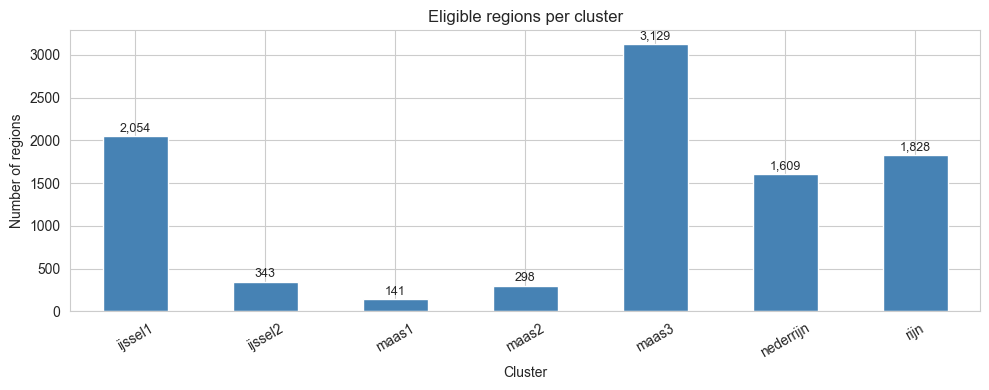

In [20]:
cluster_counts = features['cluster'].value_counts().reindex(CLUSTERS + ['other']).dropna()

print('Eligible regions per cluster (before split):')
print(f'  {"cluster":<12} {"n_regions":<12} {"% of eligible"}')
for cluster, count in cluster_counts.items():
    pct = count / len(features) * 100
    bar = '█' * int(pct / 2)
    print(f'  {cluster:<12} {int(count):<12,} {pct:>5.1f}%  {bar}')

fig, ax = plt.subplots(figsize=(10, 4))
cluster_counts.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Eligible regions per cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of regions')
ax.tick_params(axis='x', rotation=30)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Stratified 80/20 train/test split

Split result per cluster:


split,train,train_%,test,test_%,total
cluster,,,,,
ijssel1,1643.0,80.0,411.0,20.0,2054.0
ijssel2,274.0,79.9,69.0,20.1,343.0
maas1,113.0,80.1,28.0,19.9,141.0
maas2,239.0,80.2,59.0,19.8,298.0
maas3,2503.0,80.0,626.0,20.0,3129.0
nederrijn,1287.0,80.0,322.0,20.0,1609.0
rijn,1462.0,80.0,366.0,20.0,1828.0
TOTAL,7521.0,80.0,1881.0,20.0,9402.0


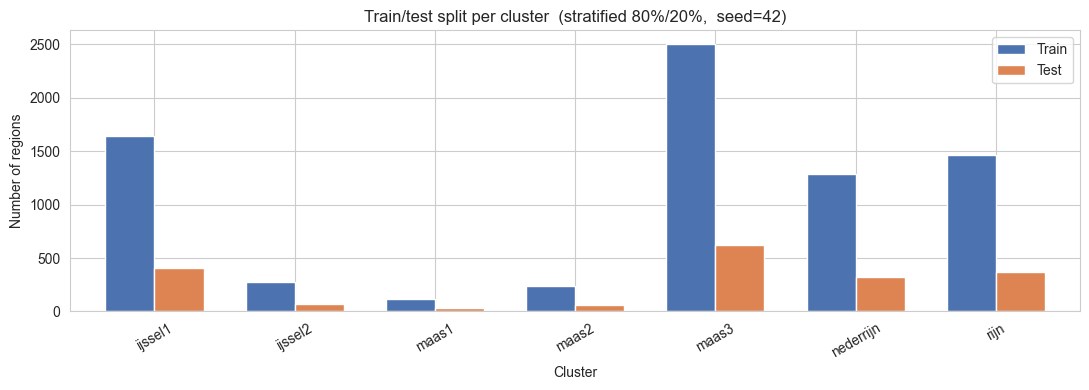

In [21]:
train_idx, test_idx = train_test_split(
    features.index,
    test_size    = TEST_SIZE,
    random_state = RANDOM_SEED,
    stratify     = features['cluster'],
)

features['split'] = 'train'
features.loc[test_idx, 'split'] = 'test'

split_counts = features.groupby(['cluster', 'split']).size().unstack(fill_value=0)
split_counts['total']   = split_counts.sum(axis=1)
split_counts['test_%']  = (split_counts['test']  / split_counts['total'] * 100).round(1)
split_counts['train_%'] = (split_counts['train'] / split_counts['total'] * 100).round(1)
totals = split_counts[['train', 'test', 'total']].sum()
totals['test_%']  = round(totals['test']  / totals['total'] * 100, 1)
totals['train_%'] = round(totals['train'] / totals['total'] * 100, 1)
split_counts.loc['TOTAL'] = totals

print('Split result per cluster:')
display(split_counts[['train', 'train_%', 'test', 'test_%', 'total']])

fig, ax = plt.subplots(figsize=(11, 4))
split_counts.drop('TOTAL')[['train', 'test']].plot.bar(
    ax=ax, color=['#4c72b0', '#dd8452'], edgecolor='white', width=0.7
)
ax.set_title(f'Train/test split per cluster  (stratified {1-TEST_SIZE:.0%}/{TEST_SIZE:.0%},  seed={RANDOM_SEED})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of regions')
ax.tick_params(axis='x', rotation=30)
ax.legend(['Train', 'Test'])
plt.tight_layout()
plt.show()

## 9. NVO check — are nature-friendly banks fairly represented?

is_nvo loaded from existing region_split.parquet
NVO regions: 2,310 / 9,402  (24.6%)
NVO fraction per split:


,n_total,n_nvo,nvo_pct
split,,,
test,1881,475,25.25
train,7521,1835,24.40


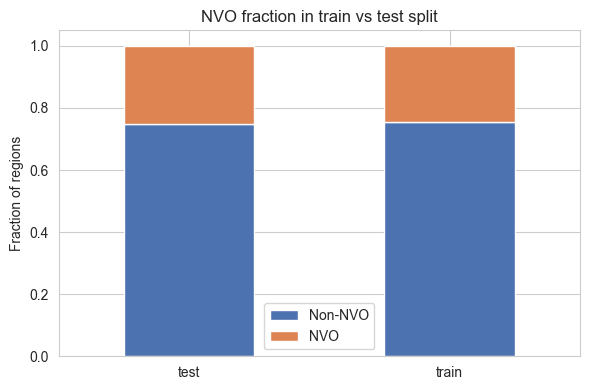

In [35]:
# Load is_nvo from an existing region_split.parquet (produced by a previous run).
# This is a workaround: is_nvo lives in the processed split file, not in the raw data.
if SPLIT_OUT.exists():
    _old = pd.read_parquet(SPLIT_OUT)
    if "is_nvo" in _old.columns:
        features["is_nvo"] = features.index.map(_old["is_nvo"]).fillna(False).astype(bool)
        n_nvo   = features["is_nvo"].sum()
        n_total = len(features)
        print(f"is_nvo loaded from existing region_split.parquet")
        print(f"NVO regions: {n_nvo:,} / {n_total:,}  ({n_nvo/n_total*100:.1f}%)")

        nvo_split = features.groupby("split").agg(
            n_total=("is_nvo", "count"),
            n_nvo  =("is_nvo", "sum"),
        ).assign(nvo_pct=lambda d: (d["n_nvo"] / d["n_total"] * 100).round(2))
        print("NVO fraction per split:")
        display(nvo_split)

        fig, ax = plt.subplots(figsize=(6, 4))
        (
            features.groupby(["split", "is_nvo"]).size().unstack(fill_value=0)
            .div(features.groupby("split").size(), axis=0)
            .plot.bar(ax=ax, stacked=True, color=["#4c72b0", "#dd8452"],
                      edgecolor="white", width=0.5)
        )
        ax.set_title("NVO fraction in train vs test split")
        ax.set_ylabel("Fraction of regions")
        ax.set_xlabel("")
        ax.legend(["Non-NVO", "NVO"])
        ax.tick_params(axis="x", rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        features["is_nvo"] = False
        print("Existing region_split.parquet has no is_nvo column — setting False for all regions.")
else:
    features["is_nvo"] = False
    print("No existing region_split.parquet — is_nvo set to False for all regions.")
    print("Re-run this cell after a prior split exists if NVO balance matters.")

## 10. Distribution sanity check

Distribution check — train and test sets should look similar:
                      value
train v_train mean   -0.030
test  v_train mean   -0.035
train v_test  mean    0.535
test  v_test  mean    0.683
train dist_t2 mean  121.550
test  dist_t2 mean  121.488


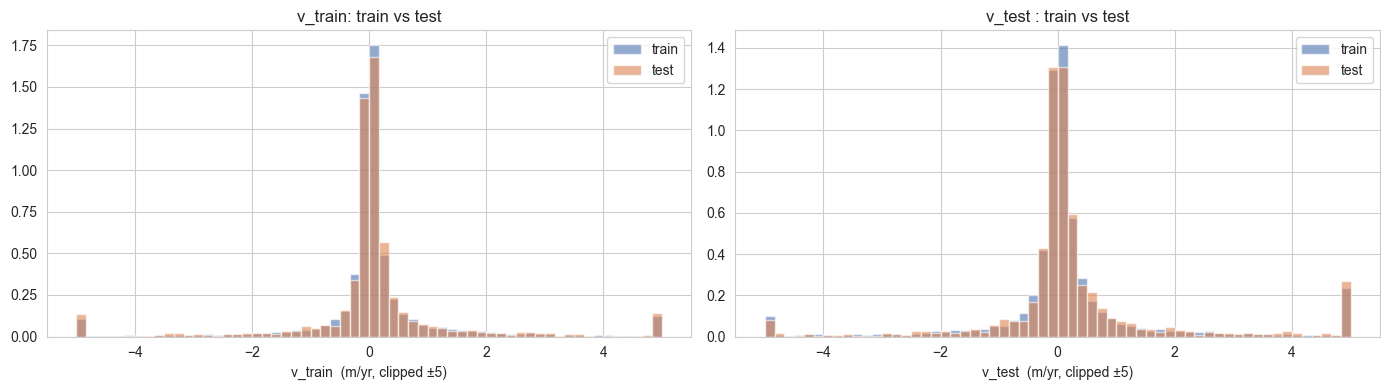

In [36]:
train = features[features['split'] == 'train']
test  = features[features['split'] == 'test']

check = pd.DataFrame({
    'train v_train mean' : [train['v_train'].mean()],
    'test  v_train mean' : [test['v_train'].mean()],
    'train v_test  mean' : [train['v_test'].mean()],
    'test  v_test  mean' : [test['v_test'].mean()],
    'train dist_t2 mean' : [train['dist_t2'].mean()],
    'test  dist_t2 mean' : [test['dist_t2'].mean()],
}).T.rename(columns={0: 'value'})
print('Distribution check — train and test sets should look similar:')
print(check.round(3).to_string())

CLIP = 5
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in [
    (axes[0], 'v_train', 'v_train: train vs test'),
    (axes[1], 'v_test',  'v_test : train vs test'),
]:
    train[col].clip(-CLIP, CLIP).hist(bins=60, ax=ax, alpha=0.6,
                                      color='#4c72b0', label='train', density=True)
    test[col].clip(-CLIP, CLIP).hist( bins=60, ax=ax, alpha=0.6,
                                      color='#dd8452', label='test',  density=True)
    ax.set_title(title)
    ax.set_xlabel(f'{col}  (m/yr, clipped ±{CLIP})')
    ax.legend()
plt.tight_layout()
plt.show()

## 11. Save outputs

In [37]:
features.to_parquet(SPLIT_OUT)
inference_df.to_parquet(INFERENCE_OUT)

print('Saved outputs:')
print(f'  {PROCESSED_OUT.name:<45}  {processed.shape}  (written earlier in this run)')
print(f'  {SPLIT_OUT.name:<45}  {features.shape}')
print(f'  {INFERENCE_OUT.name:<45}  {inference_df.shape}')
print()
print(f'Run timestamp : {RUN_TIMESTAMP}')
print(f'Input GPKG    : {GPKG_PATH.name}')
print(f'  Bank points : {len(bank_points):,}')
print(f'  Scope regions: {len(scope_regions):,}')
print(f'  Eligible (3 ts): {len(features):,}  →  train {len(train):,} / test {len(test):,}')
print(f'  Inference-only : {len(inference_df):,}')
print()
print('All model notebooks (erosion_rate_prediction, model_evaluation) can now be re-run.')

Saved outputs:
  processed_erosion_data.parquet                 (30228, 2)  (written earlier in this run)
  region_split.parquet                           (9402, 14)
  region_inference_only.parquet                  (1082, 5)

Run timestamp : 2026-03-04 11:41
Input GPKG    : wocu_output_fase2_20260210.gpkg
  Bank points : 4,844,655
  Scope regions: 12,130
  Eligible (3 ts): 9,402  →  train 7,521 / test 1,881
  Inference-only : 1,082

All model notebooks (erosion_rate_prediction, model_evaluation) can now be re-run.
